In [1]:
from src.preprocessing import rfm_df_preprocessing
rfm_df, rfm_scaled_df = rfm_df_preprocessing("../01_data/processed/model_df.csv")

In [2]:
rfm_df

,activity_score,adjusted_frequency,Monetary,Engagement,subscription_risk,support_pressure
0,46,139.108484,22.391362,119,2,1
1,37,1.000403,29.294210,70,3,0
2,38,232.187706,15.400312,207,2,2
3,24,426.224473,22.842084,192,4,1
4,47,233.343691,23.151163,138,3,2
...,...,...,...,...,...,...
124995,41,48.833931,29.161399,311,4,0
124996,30,104.340966,44.744198,275,2,0
124997,28,7.847359,15.200073,158,0,1
124998,9,409.269716,35.270053,79,4,2


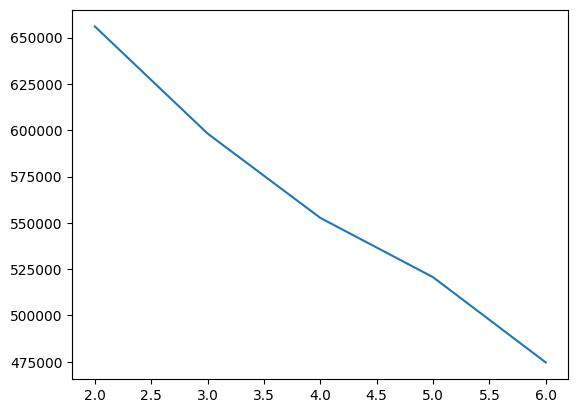

In [2]:
from src.utils import elbow_graph
elbow_graph(rfm_scaled_df)

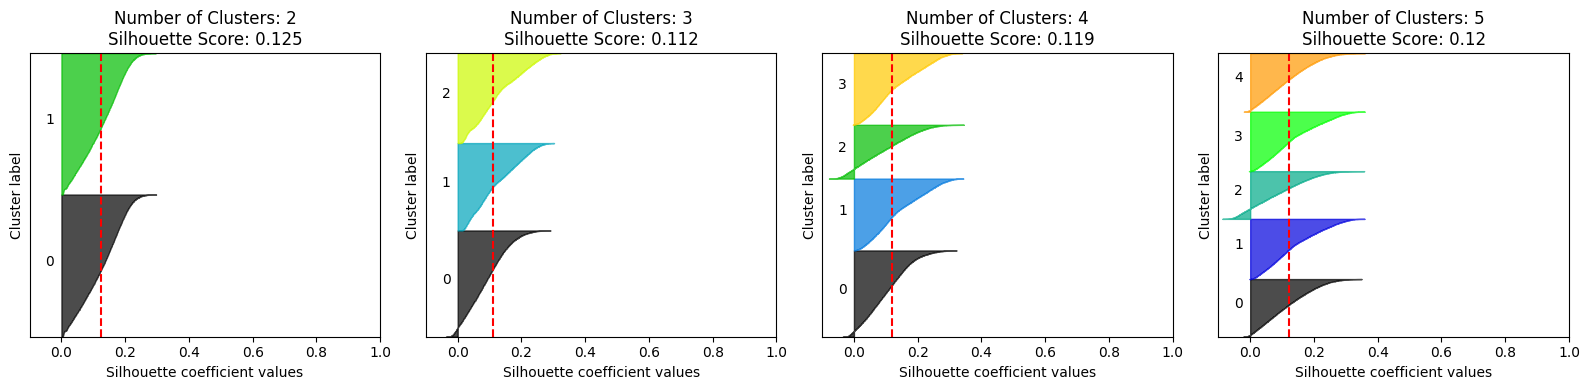

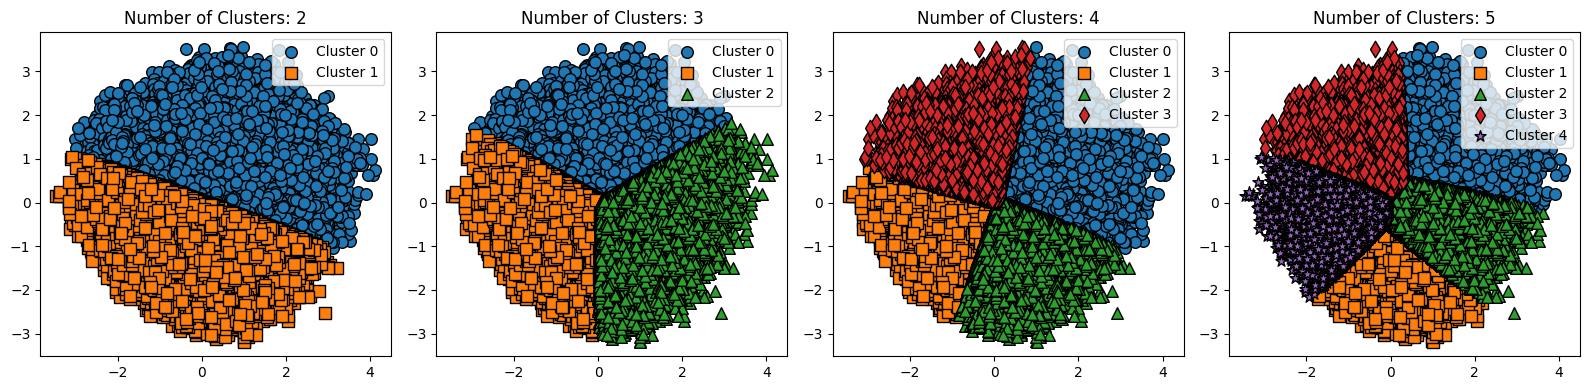

In [3]:
#⚠️실행 30분 걸림 주의!! 가급적 실행하지 마시오(시간 많을때만..)
from src.utils import visualize_kmeans_cluster
from src.utils import visualize_silhouette

visualize_silhouette([2, 3, 4, 5], rfm_scaled_df)
visualize_kmeans_cluster([2, 3, 4, 5], rfm_scaled_df)

In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(rfm_scaled_df)

rfm_df['cluster'] = labels
rfm_df

,activity_score,adjusted_frequency,Monetary,Engagement,subscription_risk,support_pressure,cluster
0,46,139.108484,22.391362,119,2,1,3
1,37,1.000403,29.294210,70,3,0,3
2,38,232.187706,15.400312,207,2,2,3
3,24,426.224473,22.842084,192,4,1,1
4,47,233.343691,23.151163,138,3,2,3
...,...,...,...,...,...,...,...
124995,41,48.833931,29.161399,311,4,0,3
124996,30,104.340966,44.744198,275,2,0,2
124997,28,7.847359,15.200073,158,0,1,0
124998,9,409.269716,35.270053,79,4,2,1


In [4]:
rfm_df['cluster'].value_counts()

cluster
0    31410
3    31388
2    31243
1    30959
Name: count, dtype: int64

In [5]:
# 각 군집별 요약본
rfm_df.groupby('cluster').mean().T

cluster,0,1,2,3
activity_score,23.696307,10.835912,24.988189,38.083981
adjusted_frequency,127.954187,123.302717,125.029824,125.033974
Monetary,11.321542,25.992302,38.569571,24.349710
Engagement,177.666285,175.953810,169.192395,172.096311
subscription_risk,0.827857,3.166834,0.818967,3.162387
support_pressure,0.998758,1.014665,0.977275,1.000159
